In [1]:
# 06_PatchTSTForecaster_model_augmented_data.ipynb

import os
import sys
from google.colab import drive, userdata
# from src.models import PatchTSTForecaster

# Mount Drive
drive.mount('/content/drive')

# Clone repo (use your GITHUB_TOKEN secret)
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = 'jesseingraham'
REPO_NAME = 'comp-653-stock-prediction-i'
REPO_PATH = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_PATH):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'comp-653-stock-prediction-i'...
remote: Enumerating objects: 303, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 303 (delta 75), reused 105 (delta 52), pack-reused 150 (from 1)
Receiving objects: 100% (303/303), 2.24 MiB | 328.00 KiB/s, done.
Resolving deltas: 100% (148/148), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.2 MB/s eta 0:00:00


In [2]:
%%writefile /content/comp-653-stock-prediction-i/src/models/patchtst_forecaster.py
import torch
import torch.nn as nn

class PatchTSTForecaster(nn.Module):
    def __init__(self, input_dim, horizon=1, patch_len=8, stride=4,
                 d_model=64, n_heads=4, n_layers=3, dropout=0.1, **kwargs):
        super().__init__()
        self.input_dim = input_dim
        self.horizon = horizon
        self.patch_len = patch_len
        self.stride = stride

        # Flatten each patch across all features
        self.patch_embed = nn.Linear(patch_len * input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        batch, seq_len, _ = x.shape
        # Pad to make sequence divisible by stride (optional)
        pad_len = (self.stride - (seq_len % self.stride)) % self.stride
        if pad_len:
            x = torch.cat([x, torch.zeros(batch, pad_len, self.input_dim, device=x.device)], dim=1)
            seq_len += pad_len

        # Extract patches using unfold
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)
        # patches shape: (batch, num_patches, input_dim, patch_len)
        patches = patches.permute(0, 1, 3, 2).contiguous()
        patches = patches.view(batch, -1, self.patch_len * self.input_dim)

        patch_embeds = self.patch_embed(patches)          # (batch, num_patches, d_model)
        encoded = self.transformer(patch_embeds)          # (batch, num_patches, d_model)
        pooled = encoded.mean(dim=1)                      # (batch, d_model)
        out = self.head(pooled)                           # (batch, horizon)
        return out

Writing /content/comp-653-stock-prediction-i/src/models/patchtst_forecaster.py


In [3]:
%%writefile /content/comp-653-stock-prediction-i/src/models/__init__.py
# Makes src/models a package

Writing /content/comp-653-stock-prediction-i/src/models/__init__.py


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import DRIVE_DATA_PATH, DRIVE_MODELS_PATH
from src.features.windowing import BASELINE_WINDOWS_FILENAME
from src.models.patchtst_forecaster import PatchTSTForecaster
from src.models.trainer import tune_model, evaluate_on_test
from src.utils import artifacts, plotting
from sklearn.preprocessing import StandardScaler

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from ray import tune
from ray.tune import Tuner, TuneConfig
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch

from src.features.windowing import AUGMENTED_WINDOWS_FILENAME

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [5]:
# 1. Load data
# data = np.load(os.path.join(DRIVE_DATA_PATH, BASELINE_WINDOWS_FILENAME), allow_pickle=True)
# X = data['X'].astype('float32')
# y = data['y'].astype('float32')
# dates = data['dates'] if 'dates' in data.files else None
# print(f"X: {X.shape}, y: {y.shape}, num_features: {X.shape[-1]}")


# Written by Stage 02 (02_feature_engineering).
WINDOW_FILE = AUGMENTED_WINDOWS_FILENAME

data = np.load(os.path.join(DRIVE_DATA_PATH, WINDOW_FILE), allow_pickle=True)
X = data['X'].astype('float32')
y = data['y'].astype('float32')
dates = data['dates'] if 'dates' in data.files else None

print('X:', X.shape, '| y:', y.shape, '| num_features:', X.shape[-1])

# 2. Train / test split (same as baseline)
TEST_FRAC = 0.15
n_test = int(len(X) * TEST_FRAC)
X_dev, X_test = X[:-n_test], X[-n_test:]
y_dev, y_test = y[:-n_test], y[-n_test:]
test_dates = dates[-n_test:] if dates is not None else None

X: (4950, 30, 11) | y: (4950, 1) | num_features: 11


In [6]:
def walk_forward_splits(n, n_folds=4, val_size=None):
    """Return list of (train_idx, val_idx) for expanding window."""
    if val_size is None:
        val_size = n // (n_folds + 1)
    splits = []
    for i in range(n_folds):
        train_end = n - (n_folds - i) * val_size
        val_start = train_end
        val_end = val_start + val_size
        splits.append((range(train_end), range(val_start, val_end)))
    return splits

def train_model_on_fold(X_train, y_train, X_val, y_val, config, max_epochs, device, scaler):
    # Scale per fold
    scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
    X_train_scaled = scaler.transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)

    # Create DataLoaders
    train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                                  torch.tensor(y_train, dtype=torch.float32))
    val_dataset = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32),
                                torch.tensor(y_val, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

    # Model
    model = PatchTSTForecaster(
        input_dim=X_train.shape[-1],
        horizon=y_train.shape[1],
        patch_len=config['patch_len'],
        stride=config['stride'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        dropout=config['dropout']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.MSELoss()

    # Training loop
    model.train()
    for epoch in range(max_epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            preds.append(pred.cpu().numpy())
            targets.append(y_batch.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    return rmse

def tune_patchtst(X, y, storage_path, experiment_name='patchtst_augmented_tune',
                  gpu_per_trial=0.0, scaler_factory=StandardScaler,
                  num_samples=30, max_epochs=50, n_folds=4, **kwargs):
    """Tune PatchTST using ray.tune with walk-forward CV."""

    # from ray import tune
    # from ray.tune import Tuner, TuneConfig
    # from ray.tune.schedulers import ASHAScheduler
    # from ray.tune.search.optuna import OptunaSearch

    search_space = {
        "patch_len": tune.choice([4, 8, 16]),
        "stride": tune.choice([2, 4]),  # <= min(patch_len)=4, so patches tile without gaps
        "d_model": tune.choice([32, 64, 128]),
        "n_heads": tune.choice([2, 4, 8]),
        "n_layers": tune.choice([1, 2, 3]),
        "dropout": tune.uniform(0.1, 0.5),
        "lr": tune.loguniform(1e-4, 1e-2),
        "batch_size": tune.choice([32, 64, 128]),
        "weight_decay": tune.loguniform(1e-5, 1e-3),
    }

    device = "cuda" if torch.cuda.is_available() else "cpu"
    splits = walk_forward_splits(len(X), n_folds=n_folds)

    def trainable(config):
        val_rmses = []
        for train_idx, val_idx in splits:
            X_train, y_train = X[train_idx], y[train_idx]
            X_val, y_val = X[val_idx], y[val_idx]
            scaler = StandardScaler() if scaler_factory is None else scaler_factory()
            rmse = train_model_on_fold(X_train, y_train, X_val, y_val,
                                       config, max_epochs, device, scaler)
            val_rmses.append(rmse)
        mean_rmse = np.mean(val_rmses)
        # tune.report(val_rmse=mean_rmse)
        tune.report({"val_rmse": mean_rmse})

    # Scheduler: metric and mode defined here
    scheduler = ASHAScheduler(
        metric="val_rmse",
        mode="min",
        max_t=max_epochs,
        grace_period=5
    )

    # Search algorithm: also needs metric and mode
    search_alg = OptunaSearch(metric="val_rmse", mode="min")

    tuner = Tuner(
        trainable,
        param_space=search_space,
        tune_config=TuneConfig(
            scheduler=scheduler,
            search_alg=search_alg,
            num_samples=num_samples,
            # No metric/mode here – they are on scheduler & search_alg
            **kwargs
        ),
        run_config=ray.air.RunConfig(
            storage_path=storage_path,
            name=experiment_name,
        ),
    )
    return tuner.fit()

In [7]:
# 3. Tune PatchTST
import ray
ray.init(ignore_reinit_error=True, include_dashboard=False)

# Define PatchTST search space
from ray import tune

search_space = {
    "patch_len": tune.choice([4, 8, 16]),
    "stride": tune.choice([2, 4]),  # <= min(patch_len)=4, so patches tile without gaps
    "d_model": tune.choice([32, 64, 128]),
    "n_heads": tune.choice([2, 4, 8]),
    "n_layers": tune.choice([1, 2, 3]),
    "dropout": tune.uniform(0.1, 0.5),
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([32, 64, 128]),
    "weight_decay": tune.loguniform(1e-5, 1e-3),
}

SMOKE_TEST = False
tune_kwargs = (
    dict(num_samples=4, max_epochs=6, n_folds=3)
    if SMOKE_TEST
    else dict(num_samples=30, max_epochs=50, n_folds=4)
)

# Budget comes straight from tune_kwargs -- the same dict that sets the final
# fit's max_epochs (step 5) and the saved manifest (step 6). Inlining the
# numbers here is what let this notebook tune at 8x15 while reporting 30x50.
results = tune_patchtst(
    X_dev, y_dev,
    storage_path=DRIVE_MODELS_PATH,
    experiment_name='patchtst_tune',
    gpu_per_trial=0.25 if torch.cuda.is_available() else 0.0,
    **tune_kwargs,
)

best = results.get_best_result('val_rmse', mode='min')
print("Best config:", best.config)
print("Best mean val RMSE:", round(best.metrics['val_rmse'], 5))


2026-08-15 22:01:37,895	INFO worker.py:2024 -- Started a local Ray instance.
[I 2026-08-15 22:01:43,070] A new study created in memory with name: optuna


+----------------------------------------------------------+
| Configuration for experiment     patchtst_tune           |
+----------------------------------------------------------+
| Search algorithm                 SearchGenerator         |
| Scheduler                        AsyncHyperBandScheduler |
| Number of trials                 30                      |
+----------------------------------------------------------+

View detailed results here: /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/patchtst_tune
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-08-15_22-01-31_691256_2163/artifacts/2026-08-15_22-01-43/patchtst_tune/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-08-15 22:01:43. Total running time: 0s
Logical resource usage: 1.0/8 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+---------------------------------------------------------------------------------------------------------------------------

2026-08-15 22:13:43,909	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/content/drive/Shareddrives/COMP 653 - Final Project/saved_models/patchtst_tune' in 0.5814s.



Trial status: 30 TERMINATED
Current time: 2026-08-15 22:13:43. Total running time: 12min 0s
Logical resource usage: 1.0/8 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name           status         patch_len     stride     d_model     n_heads     n_layers     dropout            lr     batch_size     weight_decay     iter     total time (s)     val_rmse |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| trainable_c17a4071   TERMINATED             4          4          64           4            1    0.371309   0.000343405             64      2.4808e-05         1            58.226     0.015997  |
| trainable_92dfee27   TERMINATED           

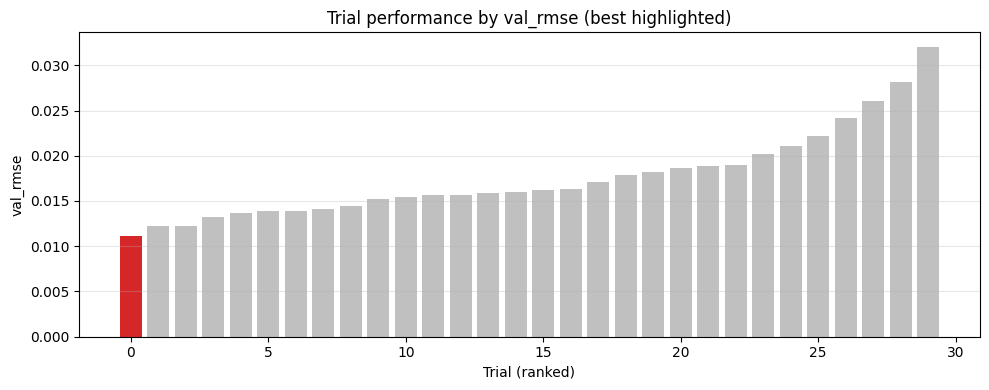

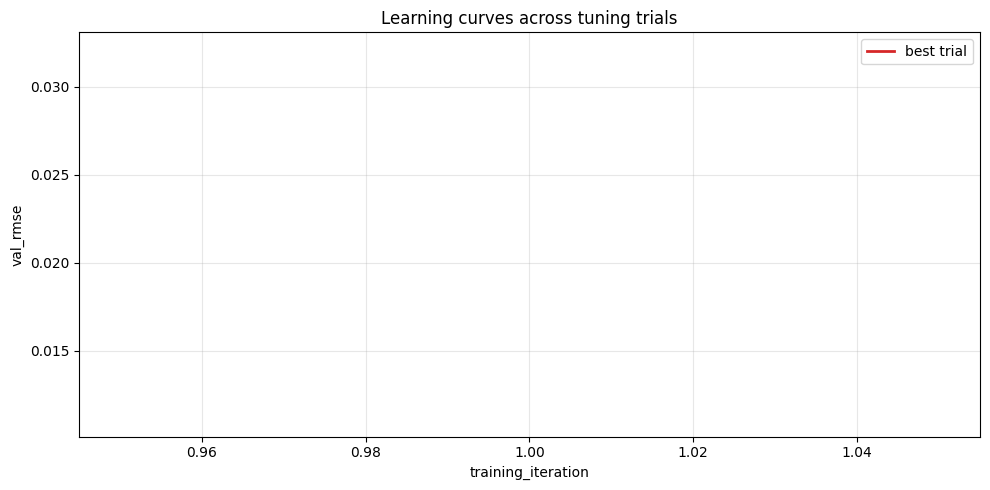

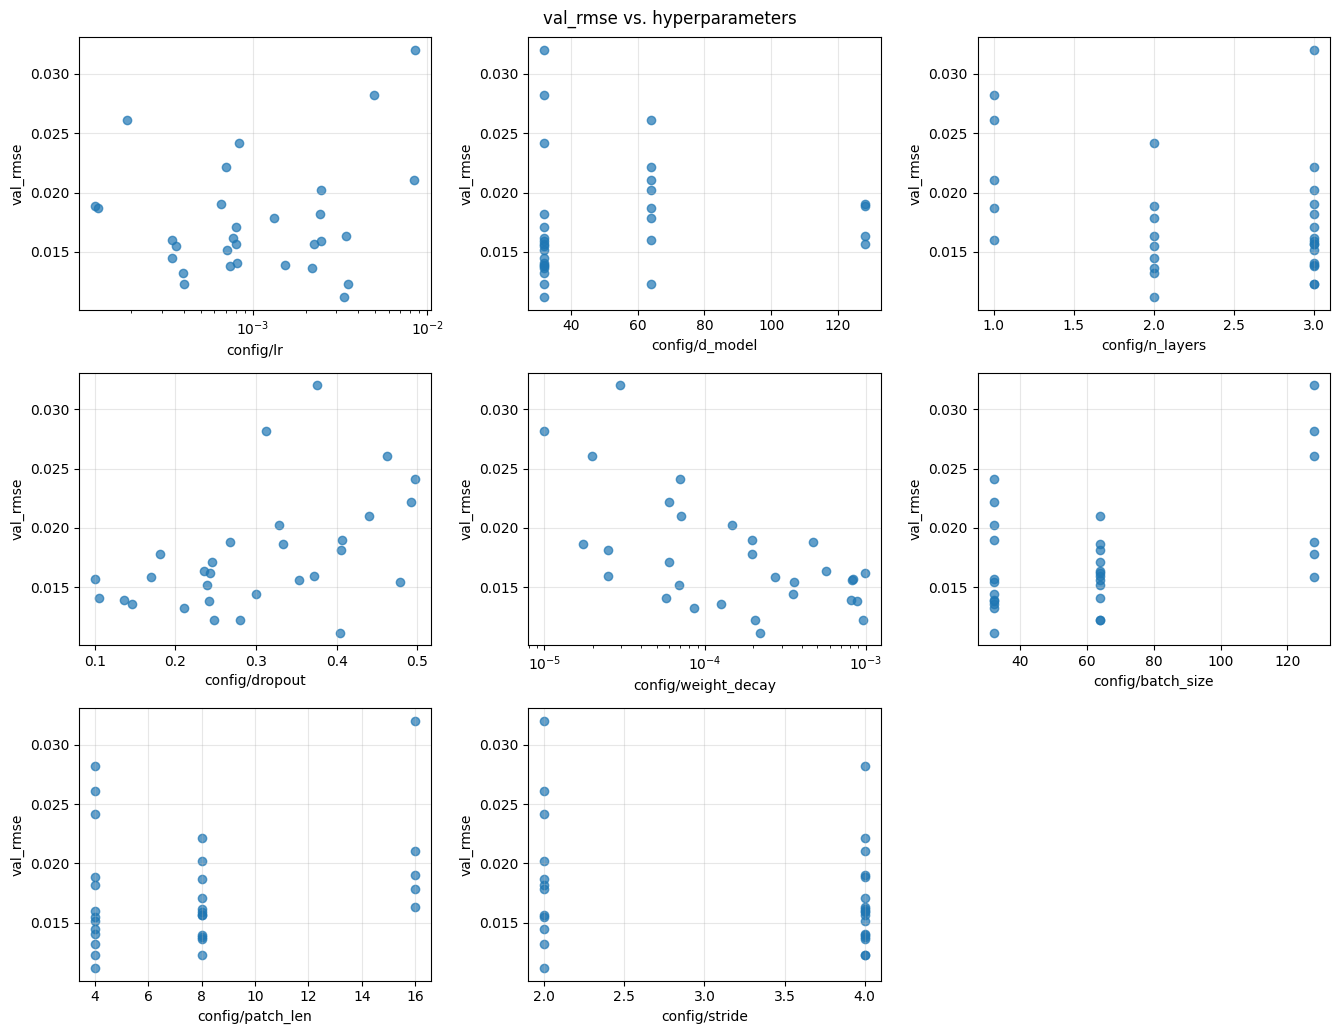

In [8]:
# 4. Tuning summary plots
results_df = results.get_dataframe()
# results_df.sort_values('val_rmse').head(10)
results_df.sort_values(ascending=False, by='val_rmse').head(10)

plotting.plot_trial_performance(results_df, metric='val_rmse', mode='min')
plt.show()

curves = [r.metrics_dataframe for r in results]
final_vals = [c['val_rmse'].iloc[-1] if 'val_rmse' in c else np.inf for c in curves]
best_index = int(np.argmin(final_vals))
plotting.plot_learning_curves(curves, metric='val_rmse', best_index=best_index)
plt.show()

params = ['config/lr', 'config/d_model', 'config/n_layers', 'config/dropout',
          'config/weight_decay', 'config/batch_size', 'config/patch_len', 'config/stride']
plotting.plot_hyperparameter_effects(results_df, params, metric='val_rmse')
plt.show()


In [9]:
def evaluate_patchtst(config, X_dev, y_dev, X_test, y_test,
                      max_epochs=50, scaler_factory=StandardScaler, device=None):
    """Train PatchTST on all dev data, evaluate on test set."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Scale per feature, pooled across timesteps -- the same convention as
    # train_model_on_fold and trainer._scale_features. Fitting on the flattened
    # window instead gives one scaler per (timestep, feature) cell, so the final
    # model would be trained under preprocessing the tuning never evaluated.
    scaler = scaler_factory() if scaler_factory else StandardScaler()
    num_features = X_dev.shape[-1]
    X_dev_scaled = scaler.fit_transform(
        X_dev.reshape(-1, num_features)
    ).reshape(X_dev.shape)
    X_test_scaled = scaler.transform(
        X_test.reshape(-1, num_features)
    ).reshape(X_test.shape)

    # Tensors
    X_dev_t = torch.tensor(X_dev_scaled, dtype=torch.float32)
    y_dev_t = torch.tensor(y_dev, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

    train_dataset = TensorDataset(X_dev_t, y_dev_t)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)

    # Build model
    model = PatchTSTForecaster(
        input_dim=X_dev.shape[-1],
        horizon=y_dev.shape[1],
        patch_len=config['patch_len'],
        stride=config['stride'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        dropout=config['dropout']
    ).to(device)

    # ----- REQUIRED ATTRIBUTES for artifacts.save_run -----
    model.num_features = X_dev.shape[-1]
    model.output_size = y_dev.shape[1]
    # Provide numeric placeholders (they won't be used for PatchTST)
    model.hidden_size = 0
    model.num_layers = 0
    model.dropout = 0.0

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.MSELoss()

    # Training loop
    train_loss_history = []
    model.train()
    for epoch in range(max_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
        epoch_loss /= len(train_loader.dataset)
        train_loss_history.append(epoch_loss)

    # Test evaluation
    model.eval()
    with torch.no_grad():
        X_test_t = X_test_t.to(device)
        preds_t = model(X_test_t)
        preds = preds_t.cpu().numpy()
        targets = y_test

    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    direction_accuracy = np.mean((np.sign(preds) == np.sign(targets)).astype(float))

    return {
        'model': model,
        'scaler': scaler,
        'test_rmse': rmse,
        'test_directional_accuracy': direction_accuracy,
        'predictions': preds,
        'targets': targets,
        'train_loss_history': train_loss_history,
    }

Test RMSE: 0.00991
Test directional accuracy: 0.445


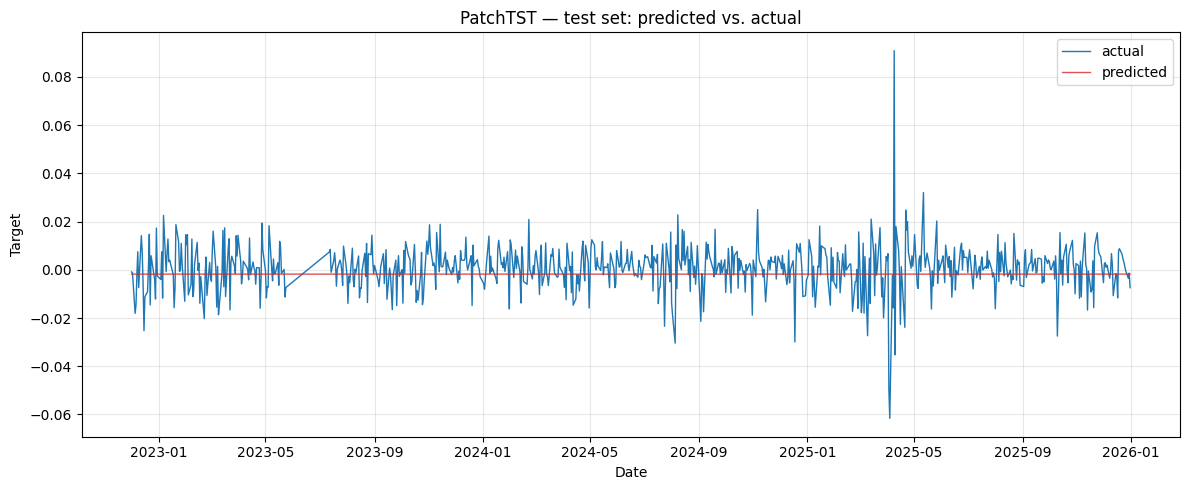

In [10]:
# 5. Final evaluation on test set
res = evaluate_patchtst(
    best.config,
    X_dev, y_dev,
    X_test, y_test,
    max_epochs=tune_kwargs['max_epochs'],
    scaler_factory=StandardScaler
)

print(f"Test RMSE: {res['test_rmse']:.5f}")
print(f"Test directional accuracy: {res['test_directional_accuracy']:.3f}")

plotting.plot_predictions_vs_actual(
    res['targets'], res['predictions'], index=test_dates,
    title='PatchTST — test set: predicted vs. actual',
)
plt.show()

In [11]:
# 6. Save run
run_dir = artifacts.save_run(
    'patchtst_augmented',
    res['model'],
    best.config,
    metrics={
        'test_rmse': res['test_rmse'],
        'test_directional_accuracy': res['test_directional_accuracy'],
        'best_val_rmse': best.metrics['val_rmse'],
    },
    scaler=res['scaler'],
    trials=results_df,
    learning_curves=curves,
    predictions=res['predictions'],
    targets=res['targets'],
    dates=test_dates,
    train_loss_history=res['train_loss_history'],
    extra_metadata={
        'dataset_file': WINDOW_FILE,
        'window_shape': list(X.shape),
        'num_features': int(X.shape[-1]),
        'horizon': int(y.shape[-1]),
        'n_dev': int(len(X_dev)),
        'n_test': int(len(X_test)),
        'test_frac': TEST_FRAC,
        'n_folds': tune_kwargs['n_folds'],
        'num_samples': tune_kwargs['num_samples'],
        'max_epochs': tune_kwargs['max_epochs'],
        'scaler': 'StandardScaler',
        'smoke_test': SMOKE_TEST,
    }
)

print("Saved run ->", run_dir)
for item in sorted(os.listdir(run_dir)):
    print("  ", item)

Saved run -> /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/patchtst_augmented_20260815_221425
   learning_curves.csv
   manifest.json
   model.pt
   scaler.joblib
   test_predictions.csv
   tuning_trials.csv
